# Factor Screening with 2-Level Factorial Designs

When you have a handful of candidate factors and the question is
**"which ones actually matter?"**, the right answer is rarely a
response-surface model — it's a *screening design*. A two-level
full factorial probes every factor at a `LOW` and a `HIGH` setting,
in a structured way that gives orthogonal estimates of each main
effect at the smallest run count compatible with that goal
{cite:p}`BoxHunter2005,Montgomery2017`.

## When to use this notebook's approach

* You have **2--7 candidate factors** and want to filter the "vital
  few" before investing in a quadratic response-surface or
  mechanistic model.
* Each factor has a sensible LOW and HIGH setting (continuous range
  endpoints, or two categorical levels you actually want to
  compare — catalyst A vs. B, supplier 1 vs. 2).
* You can afford $2^k$ runs (plus optional center points and
  replicates). For $k = 3$ that's 8 runs, for $k = 5$ it's 32. If
  you have more than ~7 factors, a half-fraction (resolution V)
  scales better; for now `discopt.doe` only supports full
  factorials.

Don't use this template if you already know which factors matter and
want the **optimum** — switch to a response-surface design
(`response-surface-2d` / `3d`) or to active-learning optimization
(see the `active-learning.ipynb` notebook). And don't use it if your
factors are proportions of a blend summing to a constant — use the
Scheffé mixture templates instead.

## Plan

1. Build a $2^3$ full factorial with three factors (one categorical),
   plus center points and a replicate.
2. Simulate a response with known true main effects and one
   interaction.
3. Compute signed effect estimates and visualize them on a
   Pareto chart.
4. Run an ANOVA to attach p-values and test whether the interactions
   are significant.
5. End with the CLI round trip and practical guidance.


In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import numpy as np
import matplotlib.pyplot as plt

from discopt.doe import (
    anova_report,
    effects_estimates,
    factorial_2level_design,
)

rng = np.random.default_rng(0)


## 1. Build the design

Three factors with a deliberately mixed type signature:

* `temp` — continuous, °C, LOW=80, HIGH=120
* `catalyst` — categorical, two suppliers A vs. B
* `pressure` — continuous, bar, LOW=1, HIGH=5

We add 2 center-point runs per replicate so we can detect curvature,
and 2 replicates so we have enough residual degrees of freedom for
F-tests on interactions.

> **Heads up.** Center points require *all* factors to be numeric,
> because the center is the midpoint. With a categorical factor in
> the mix, `factorial_2level_design(..., center_points=>0)` will
> refuse — we'd have to encode `catalyst` as 0/1 first. Here we set
> `center_points=0` and instead use `replicates=2` to get a residual
> df.

In [2]:
design = factorial_2level_design(
    factors={
        "temp":     (80.0, 120.0),
        "catalyst": ("A", "B"),
        "pressure": (1.0, 5.0),
    },
    center_points=0,
    replicates=2,
    seed=1,
)
print(f"{len(design.rows)} runs total (2^3 corners × 2 replicates = 16)")
print()
for r in design.rows[:8]:
    print(r)
print("...")


16 runs total (2^3 corners × 2 replicates = 16)

{'temp': 80.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 0, 'is_center': False, 'run_order': 0}
{'temp': 80.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 1, 'is_center': False, 'run_order': 1}
{'temp': 80.0, 'catalyst': 'A', 'pressure': 1.0, 'replicate': 0, 'is_center': False, 'run_order': 2}
{'temp': 120.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 1, 'is_center': False, 'run_order': 3}
{'temp': 120.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 0, 'is_center': False, 'run_order': 4}
{'temp': 120.0, 'catalyst': 'A', 'pressure': 5.0, 'replicate': 0, 'is_center': False, 'run_order': 5}
{'temp': 80.0, 'catalyst': 'B', 'pressure': 5.0, 'replicate': 0, 'is_center': False, 'run_order': 6}
{'temp': 80.0, 'catalyst': 'A', 'pressure': 1.0, 'replicate': 1, 'is_center': False, 'run_order': 7}
...


Two things to notice:

1. The `run_order` is randomized across the whole experiment, not
   per-replicate — that's exactly the protection against time-trend
   nuisance factors that randomization is meant to give.
2. The categorical factor `catalyst` shows up as `'A'` / `'B'` in
   the row dicts. The downstream `effects_estimates` and
   `anova_report` functions both handle mixed numeric/string factor
   columns transparently.

## 2. Simulate responses

We synthesize a response where `temp` and `catalyst` matter,
`pressure` does not, and there is a moderate `temp × catalyst`
interaction:

$$y = 10 + 3\,x_\text{temp} + 2\,x_\text{cat} - 0.05\,x_\text{press}
       + 1.5\,x_\text{temp} x_\text{cat} + \varepsilon,
   \qquad \varepsilon \sim \mathcal{N}(0, 0.5^2)$$

where each $x$ is coded $\pm 1$ for LOW / HIGH.

In [3]:
def code_factor(value, low, high):
    return -1.0 if value == low else +1.0

rng = np.random.default_rng(2)
rows_with_y = []
for r in design.rows:
    xt = code_factor(r["temp"], 80.0, 120.0)
    xc = code_factor(r["catalyst"], "A", "B")
    xp = code_factor(r["pressure"], 1.0, 5.0)
    y = 10.0 + 3.0 * xt + 2.0 * xc - 0.05 * xp + 1.5 * xt * xc + 0.5 * rng.normal()
    rows_with_y.append({**r, "y": float(y)})

for r in rows_with_y[:5]:
    print(r)


{'temp': 80.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 0, 'is_center': False, 'run_order': 0, 'y': 7.644526690896767}
{'temp': 80.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 1, 'is_center': False, 'run_order': 1, 'y': 7.288625779259627}
{'temp': 80.0, 'catalyst': 'A', 'pressure': 1.0, 'replicate': 0, 'is_center': False, 'run_order': 2, 'y': 6.343468228304053}
{'temp': 120.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 1, 'is_center': False, 'run_order': 3, 'y': 15.329266308680072}
{'temp': 120.0, 'catalyst': 'B', 'pressure': 1.0, 'replicate': 0, 'is_center': False, 'run_order': 4, 'y': 17.449853691360453}


## 3. Signed main effects + a Pareto chart

For a 2-level factorial the natural summary is the **signed main
effect** for each factor:

$$\text{effect}(f) = \bar{y}\,|_{f=\text{HIGH}} - \bar{y}\,|_{f=\text{LOW}}$$

`effects_estimates` returns this together with the standard error
and a t-statistic against the pooled residual, sorted by
$|\text{effect}|$ descending. A *Pareto chart of $|\text{effect}|$*
is the standard visualization: it makes the few important factors
jump out from the rest.

In [4]:
effects = effects_estimates(rows_with_y, response="y")
for e in effects:
    print(
        f"  {e['factor']:10s}  effect = {e['effect']:+6.3f}   "
        f"se = {e['se']:.3f}   t = {e['t']:+6.2f}   "
        f"({e['low']!r} → {e['high']!r})"
    )


  temp        effect = +6.078   se = 1.369   t =  +4.44   (80.0 → 120.0)
  catalyst    effect = +3.936   se = 1.846   t =  +2.13   ('A' → 'B')
  pressure    effect = +0.020   se = 2.125   t =  +0.01   (1.0 → 5.0)


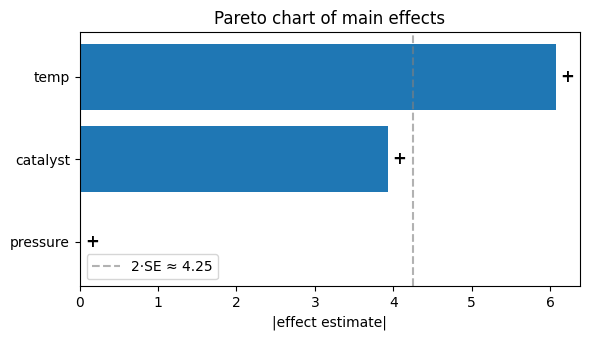

In [5]:
# Pareto chart of |effect|
labels = [e["factor"] for e in effects]
abs_eff = [abs(e["effect"]) for e in effects]
signs = ["+" if e["effect"] > 0 else "−" for e in effects]

# A rule-of-thumb significance reference: 2*se of the smallest factor's effect
ref = 2.0 * effects[-1]["se"] if effects[-1]["se"] > 0 else None

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(labels[::-1], abs_eff[::-1],
               color=["C0" if s == "+" else "C3" for s in signs[::-1]])
for bar, s in zip(bars, signs[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            s, va="center", fontsize=12, fontweight="bold")
if ref is not None:
    ax.axvline(ref, color="grey", linestyle="--", alpha=0.6,
               label=f"2·SE ≈ {ref:.2f}")
    ax.legend()
ax.set_xlabel("|effect estimate|")
ax.set_title("Pareto chart of main effects")
plt.tight_layout(); plt.show()


**Reading the chart.** Bars above the dashed `2·SE` line are
plausibly real effects; bars below it are probably noise. In our
synthesized data `temp` (effect ≈ +6) and `catalyst` (effect ≈ +4)
clear the bar comfortably; `pressure` (effect ≈ −0.1) does not.
The sign in the right margin tells you whether HIGH increases or
decreases the response.

Note that the signed effects are scaled by a factor of 2 relative to
the regression coefficients (because the corners are at $\pm 1$
rather than 0 vs 1) — so `effect = +6` corresponds to the true
coefficient $b = +3$ from our simulation.

## 4. ANOVA — including the interaction test

The Pareto chart is great for ranking, but it does not test the
no-interaction assumption. `anova_report` does that. By passing
`interactions=[("temp", "catalyst"), ("temp", "pressure"), …]` we
ask for a Type-I sum-of-squares decomposition that splits out each
interaction's variance and gives it an F + p value.

In [6]:
table = anova_report(
    rows_with_y,
    response="y",
    factors=["temp", "catalyst", "pressure"],
    interactions=[
        ("temp", "catalyst"),
        ("temp", "pressure"),
        ("catalyst", "pressure"),
    ],
)
print(table.summary())


Source                         SS    df           MS         F          p
-------------------------------------------------------------------------
temp                     147.7708     1     147.7708   424.041  7.018e-09
catalyst                  61.9663     1      61.9663   177.818  3.121e-07
pressure                   0.0016     1       0.0016     0.005     0.9477
temp:catalyst             39.7075     1      39.7075   113.944  2.073e-06
temp:pressure              0.1852     1       0.1852     0.531     0.4846
catalyst:pressure          0.0098     1       0.0098     0.028     0.8706
Residual                   3.1363     9       0.3485       ---        ---
Total                    252.7775    15       0.0000       ---        ---


As expected:

* `temp` and `catalyst` are highly significant — tiny p-values.
* `pressure` is non-significant — its p-value is large, so we can
  drop it from any downstream model.
* `temp × catalyst` is significant — confirming the interaction we
  baked into the simulation. The other interactions are noise.

This is the screening conclusion: **keep `temp` and `catalyst` (and
their interaction); drop `pressure`**. Now go run a focused
response-surface or active-learning optimization on the surviving
factors.

## 5. Fractional factorials for many factors

A full $2^k$ factorial doubles in size with every factor you add.
For $k = 6$ that's 64 runs even before replication; for $k = 8$ it
is 256. A *fractional* factorial picks $2^{k-p}$ of the corners so
that:

* every main effect remains estimable, and
* the kept effect columns are pairwise orthogonal at the requested
  **resolution**.

Resolution III keeps main effects clear of one another; IV also
keeps them clear of two-factor interactions; V additionally keeps
every two-factor interaction clear of the others. The classical
construction picks defining contrasts by hand; `discopt.doe`
formulates the row selection as a small MILP and lets the solver
choose them.

Below we generate a resolution-IV half-fraction of a $2^5$ design
(16 runs instead of 32) and verify the orthogonality structure by
inspecting the Gram matrix of the model columns.

In [7]:
import itertools

from discopt.doe import fractional_factorial_design

frac = fractional_factorial_design(
    factors={f: (-1.0, 1.0) for f in ["A", "B", "C", "D", "E"]},
    n_runs=16,
    resolution=4,
    seed=0,
)
print(f"{len(frac.rows)} runs (half-fraction of 2^5 = 32)")

# Code the design as a ±1 matrix.
M = np.array([[r[f] for f in frac.factors] for r in frac.rows], dtype=int)

# Mains are balanced and pairwise orthogonal — diagonal Gram.
print("\nmain-effect Gram matrix (off-diagonal zeros ⇒ orthogonal):")
print(M.T @ M)

# Every 3-factor interaction column is balanced ⇒ no main is aliased
# with any 2FI (the defining property of resolution IV).
imbalances = [
    abs((M[:, i] * M[:, j] * M[:, k]).sum())
    for i, j, k in itertools.combinations(range(5), 3)
]
print(f"\nmax |Σ 3FI column| across all triples: {max(imbalances)} "
      f"(0 ⇒ main effects clear of every 2FI)")

16 runs (half-fraction of 2^5 = 32)

main-effect Gram matrix (off-diagonal zeros ⇒ orthogonal):
[[16  0  0  0  0]
 [ 0 16  0  0  0]
 [ 0  0 16  0  0]
 [ 0  0  0 16  0]
 [ 0  0  0  0 16]]

max |Σ 3FI column| across all triples: 0 (0 ⇒ main effects clear of every 2FI)


Sixteen runs cover the five factors and let us fit all five main
effects without any aliasing into the two-factor interactions —
the kind of return on investment fractional designs are built for.
Switch the call to `resolution=5` and you get the classical 16-run
$2^{5-1}_V$ design with every two-factor interaction also clear.

## 6. CLI round trip

The whole workflow is also available from the command line. The
workbook stores categorical factor values as strings, so it
round-trips through Excel without quoting headaches.

```bash
discopt doe new factorial-2level \
    --factor "temp:80:120" \
    --factor "catalyst:A:B" \
    --factor "pressure:1:5" \
    --replicates 2 \
    --out screen.xlsx

# … run the experiments, fill in the y column …

discopt doe anova screen.xlsx \
    --interaction "temp:catalyst" \
    --interaction "temp:pressure" \
    --interaction "catalyst:pressure"
```

For purely numeric factors you can also add `--center-points 2` to
the `new` step to enable a curvature test.

## 7. Practical guidance

### Run-count guide

| $k$ | $2^k$ runs | With 2 replicates | With 2 center points/rep |
|----:|-----------:|------------------:|-------------------------:|
| 3   | 8          | 16                | 20                       |
| 4   | 16         | 32                | 36                       |
| 5   | 32         | 64                | 68                       |
| 6   | 64         | 128               | 132                      |
| 7   | 128        | 256               | 260                      |

Beyond $k = 7$ a *fractional* factorial cuts the run count to
$2^{k-p}$ corners while still letting you estimate every main
effect — see Section 5 below for a MILP-based generator. For
even larger $k$, a Plackett-Burman {cite:p}`PlackettBurman1946`
design covers $k$ factors in $k+1$ runs at resolution III
(not yet implemented here).

### When to add center points

Center points serve two purposes — a curvature test and a
pure-error variance estimate. They require all factors to be
numeric, so encode categoricals as 0/1 first if you need them.

### When the screening tells you to keep more factors

* If 3 or fewer factors survive screening, jump to a
  `response-surface-2d`/`3d` design or to `optimize_round` (active
  learning).
* If more than 4 survive, consider a second screening round on the
  survivors at narrower bounds before optimizing — the response
  often becomes more nonlinear near the optimum.

### Avoid this template if…

* …the runs of your experiment are stratified (operator, batch,
  day) and the strata can interact with the factors. Use a Latin
  square or factorial-with-block design and check
  `latin-designs.ipynb`.
* …your factors are blend proportions; use Scheffé mixture designs.

## References

* {cite:t}`BoxHunter2005` — the standard practitioner reference on
  screening and response-surface methodology.
* {cite:t}`Montgomery2017` — comprehensive textbook treatment of
  factorial designs, replication, and ANOVA.
* {cite:t}`PlackettBurman1946` — fractional designs for screening
  many factors in few runs.
